# Feature sifting on a multi-task linear problem

**Problem.** Stationary 2-task multi-linear (`phd/jax_core/tasks/multi_linear.py`): the linear
counterpart of multi-GEOFF, with the same block-diagonal multi-task structure and scale
conventions but no hidden layer. Two independent linear teachers, 10 inputs and 1 output each
(20 inputs, 2 outputs in total), weights in $\{-c, +c\}$ with $c$ set so the noise-free signal
has unit variance per output whatever the input range is, and $N(0, 1)$ observation noise.
Per-output MSE is 1.0 for an optimal predictor and 2.0 for the mean predictor. Because the
target is linear, a linear learner wired to the right inputs reaches 1.0 **exactly** — nothing
about the function class stands between a method and the noise floor, so what the MSE measures
is the structure the method found.

`multi_linear_sifting.py` wraps it into the **feature sifting** setting of
`phd/jax_core/tasks/feature_sifting.py`: each step the learner may cut connections, and every
cut connection is immediately replaced by a new one. The difference from the original sifting
task is that the candidate pool is *fixed* — it is the problem's own 20 inputs — so sifting
means finding which real features each output should read, not waiting for a lucky procedural
draw. The teacher is block-diagonal, so an output's 10 cross-task features are pure noise for
it and its 10 within-task ones are exactly what it needs.

**Learner.** A linear predictor per output, plus a bias. It starts with 20 connections, 10 per
output, drawn without replacement from the pool, and every weight starts at zero. A connection
is one (output, feature) pair, so an output is never wired to the same feature twice; the grid
of all such pairs is the padded weight matrix, of which only the connected positions are live
(their input is zeroed otherwise). A replacement picks a **random output** and then a **random
feature that output is free of**, so the total stays at 20 while the split between the two
outputs drifts over a run. The ideal wiring is therefore reachable: 10 connections per output,
each to one of its own task's 10 features.

**Runs.** LMS at a fixed step-size, Autostep, Autostep + generate & test (which cuts a
connection the step its weight crosses zero), that plus a subgradient L1 penalty, and Autostep +
band (which cuts a connection whose weight is inside the noise band of a dead connection of the
same age). The first two never rewire, and show what the initial random wiring is worth.

**Why the L1 variant is here.** The bare zero-crossing test is not scale-free in the way it
looks. A dead connection's weight is a random walk plus a pull toward zero, and while the pull's
*strength* and the walk's *variance* both scale with the step-size $\alpha$ — leaving the
stationary distribution zero-mean with standard deviation $\sigma_\delta\sqrt{\alpha/2}$, and so
scale-free — the *rate* of the pull is $\alpha\,\mathbb{E}[x^2]$, giving a relaxation time of
$1/(\alpha\,\mathbb{E}[x^2])$ steps that does **not** cancel. Run for less than that and the pull
is never felt: the weight is a driftless walk, whose first-return times to zero are heavy-tailed
($P(T > t)\sim t^{-1/2}$, infinite mean), so a persistent fraction of dead connections never
cross zero again and are never tested. At `INIT_LR = 1e-6` that relaxation time is
$3\times10^{6}$ steps — far beyond this run — and the search stalls with its mistakes frozen in.

L1 fixes that without touching `INIT_LR`. Its subgradient contributes a *constant-magnitude*
drift $\alpha\lambda$ against gradient noise $\alpha\sigma$, so the drift-to-noise ratio
$\lambda/\sigma$ is $\alpha$-free, and the time to be pulled back across zero from a diffusive
excursion $|w|\sim\alpha\sigma\sqrt{N\,\mathbb{E}[x^2]}$ is
$\sigma\sqrt{N\,\mathbb{E}[x^2]}/\lambda$ — with $\alpha$ cancelling outright. A dead weight is
*driven* back to zero rather than left to relax there, at any step-size.

**Why the band variant is here.** L1 fixes the stall by *driving* a dead weight back to zero; the
band variant fixes it by not waiting for zero at all. A dead connection's weight is a random walk
whose one-sigma envelope is $s = \sqrt{\alpha\,\mathbb{E}[\delta^2]/2}$ (derived in
`phd/sandbox/feature_sifting/exploration/lasso_step_size_protection_algo.ipynb`), so
"indistinguishable from dead" is testable outright, every step, with no crossing needing to happen.
The catch is that a newborn connection sits at $w = 0$ — the deepest point inside that envelope —
and at `INIT_LR` even a genuinely useful weight needs thousands of steps to climb out, so the
*stationary* band cuts every connection on arrival and the wiring never settles. Judging the weight
against the band for its own **age**, $s(t) = s\sqrt{1 - \rho^t}$ with
$\rho = \mathbb{E}[(1 - \alpha x^2)^2]$, removes that: the band opens from zero at exactly the rate a
dead weight wanders, while a useful weight's mean grows linearly and overtakes it after
$\approx 9\,\mathbb{E}[\delta^2] / (w^{*2}\,\mathbb{E}[x^2])$ steps — a step count in which
$\alpha$ cancels outright, so it holds at any step-size. That is the same $\alpha$-freedom L1 buys,
taken from the test instead of from a penalty on the loss.

In [1]:
import os
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.tasks.multi_linear import MultiLinearTask
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.analysis.analysis_utils import get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from multi_linear_sifting import MultiLinearSifting

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
# --- Problem ---
N_TASKS = 2
N_FEATURES_PER_TASK = 10
N_OUTPUTS_PER_TASK = 1
NOISE_STD = 1.0
INPUT_BOUNDS = (-1.0, 1.0)           # uniform input range, shared by every problem instance

# --- Learner ---
N_CONNECTIONS_PER_OUTPUT = 10        # the initial split; the total is conserved, the split is not

# --- Optimizers ---
LMS_LR = 0.001
INIT_LR = 1e-10                       # Autostep's starting step-size for every connection
META_LR = 0.02
L1_COEFF = 0.01                      # subgradient L1 on the connections (method 4)
BAND_TRACE_HORIZON = 1_000           # EMA horizon for the per-output E[delta^2] (method 5)

# --- Training and recording ---
NUM_STEPS = 200_000
N_SEEDS = 30                         # vmapped into one scan; scan width is nearly free
N_SNAPSHOTS = 200                    # recording points per run
BASE_SEED = 0

# --- Derived ---
N_FEATURES = N_TASKS * N_FEATURES_PER_TASK
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK
N_SLOTS = N_FEATURES + 1                 # one slot per (output, feature) pair, plus a bias column
N_CONNECTIONS = N_OUTPUTS * N_CONNECTIONS_PER_OUTPUT
IRREDUCIBLE_MSE = NOISE_STD ** 2         # per-output MSE of an optimal predictor
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0     # the mean predictor sits 1 above it
BLOCK_LEN = NUM_STEPS // N_SNAPSHOTS

## Learners

Each method is a self-contained `eqx.Module` with `init()` and `step(inputs, y, active)`, and
carries the `prune_mask` the task reads to rewire. `inputs` and `active` are the
`(n_outputs, n_features)` connection grid, padded here with the bias column; the weight matrix
covers the whole grid and unconnected positions are held inert.

In [3]:
def slot_inputs(inputs, active):
    """Pad the connection grid with the bias column: a constant-1 input, always connected.

    Keeping the bias inside the weight matrix is what Autostep's per-output-row normalizer
    needs — it does not support a separate bias vector.
    """
    ones = jnp.ones((N_OUTPUTS, 1))
    return (jnp.concatenate([inputs, ones], axis=1),
            jnp.concatenate([active, ones.astype(bool)], axis=1))


def linear_loss_and_grads(w, x, y):
    """Squared error summed over outputs, and the LMS gradient `delta * x`.

    That is the exact gradient up to the constant factor 2, which is folded into the step-size.
    An unconnected slot has `x = 0`, so it contributes nothing to either.
    """
    error = jnp.sum(w * x, axis=-1) - y
    return jnp.sum(error ** 2), error[:, None] * x


def hold_inactive(w, opt_state, active):
    """Hold every unconnected slot at its starting state: zero weight, `INIT_LR`, no traces.

    An unconnected slot's input is zeroed, so its gradient and traces are already frozen — the
    one thing that still moves it is Autostep's per-output normalizer, which divides the whole
    row. Resetting the unconnected slots every step is the simplest way to make a connection
    formed later start with no inherited history, whichever slot it lands in.
    """
    return jnp.where(active, w, 0.0), IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(active, opt_state.beta, opt_state.init_beta),
        h=jnp.where(active, opt_state.h, 0.0),
        v=jnp.where(active, opt_state.v, 0.0),
    )

In [4]:
class LMS(eqx.Module):
    """Least mean squares at a fixed step-size on the initial wiring; never rewires."""
    w: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        return cls(w=jnp.zeros((N_OUTPUTS, N_SLOTS)),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_FEATURES), dtype=bool))

    def step(self, inputs, y, active):
        x, _ = slot_inputs(inputs, active)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        return tree_replace(self, w=self.w - LMS_LR * grads), loss   # prune_mask stays all-False

In [5]:
class Autostep(eqx.Module):
    """Autostep (IDBD) on the initial wiring: a step-size per connection, but no rewiring."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_FEATURES), dtype=bool))

    def step(self, inputs, y, active):
        x, active = slot_inputs(inputs, active)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        # Autostep consumes the loss gradient and the prediction gradient (= x, this being a
        # linear model), and normalizes each output's row of step-sizes on its own — which is
        # what a loss that is a plain sum of per-output squared errors calls for.
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w, opt_state = hold_inactive(self.w + updates, opt_state, active)
        return tree_replace(self, w=w, opt_state=opt_state), loss

In [6]:
class AutostepGT(eqx.Module):
    """Autostep + generate & test: a connection is cut the step its weight crosses zero.

    The task replaces every cut connection with one between a random output and a random
    feature that output is free of, so the learner keeps the same number of weights and
    trades away the ones a real gradient is no longer holding off zero. A new connection
    arrives at exactly `w = 0` (`hold_inactive` parks every unconnected slot there), so the
    product below is zero and it is never cut on its first step.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_FEATURES), dtype=bool))

    def step(self, inputs, y, active):
        x, active = slot_inputs(inputs, active)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w, opt_state = hold_inactive(self.w + updates, opt_state, active)

        # The bias column is not a connection, so it is sliced back off the mask.
        prune_mask = ((self.w * w < 0.0) & active)[:, :N_FEATURES]
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss

In [7]:
class AutostepL1GT(eqx.Module):
    """Autostep + L1 + G&T: the same zero-crossing cut, plus a subgradient L1 penalty.

    `lambda * sign(w)` joins the loss gradient, so it drives the weight update *and* Autostep's
    step-size adaptation. Its contribution to a step is `alpha * lambda` against gradient noise
    `alpha * sigma`, so the ratio is step-size free: a dead weight is actively driven back across
    zero instead of waiting on a mean-reversion whose rate vanishes with `alpha`. That is what
    makes the cut keep firing at any `INIT_LR`, which the bare test does not.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, l1=L1_COEFF, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_FEATURES), dtype=bool))

    def step(self, inputs, y, active):
        x, active = slot_inputs(inputs, active)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        # L1 on the connections only: shrinking the bias fights the target's mean, not structure.
        # `loss` stays pure squared error, so the MSE curves remain comparable across methods.
        grads = grads + self.l1 * jnp.sign(self.w).at[:, -1].set(0.0)
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w, opt_state = hold_inactive(self.w + updates, opt_state, active)

        prune_mask = ((self.w * w < 0.0) & active)[:, :N_FEATURES]
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss

In [8]:
class AutostepBand(eqx.Module):
    """Autostep + band pruning: a connection is cut once its weight is inside the noise band of
    a dead connection **of the same age**.

    A dead connection's weight is a mean-reverting random walk whose stationary rms is the
    one-sigma band `s = sqrt(alpha * E[delta^2] / 2)` (derived in
    `phd/sandbox/feature_sifting/exploration/lasso_step_size_protection_algo.ipynb`), with
    `E[delta^2]` the *plain* squared residual of that connection's own output — traced per
    output, since the loss here is a sum over two of them — and `alpha` the step-size that
    multiplies the half-MSE gradient, which is exactly what this notebook hands the optimizer.
    `E[x^2]` cancels out of `s`, so a feature's scale does not enter.

    The **stationary** band is useless on its own: every connection is born at `w = 0`, deep
    inside it, and at `INIT_LR` a *useful* weight needs thousands of steps to climb out, so the
    test kills every connection on arrival and the wiring never settles. What the rule needs is
    the band for a weight of the connection's own age,

        s(t) = s * sqrt(m_t),    m_t = 1 - rho^t,    rho = E[(1 - alpha x^2)^2]

    which starts at zero alongside the weight and widens at exactly the rate a dead weight
    wanders. The age is accumulated per step from the realized `x`, so it keeps meaning the right
    thing while Autostep is still ramping `alpha` up from `INIT_LR`.

    That accumulation is kept as `log(1 - m_t)` rather than as `m_t` itself, because the direct
    form `m <- 1 - (1 - alpha x^2)^2 (1 - m)` cancels catastrophically in float32: once
    `alpha E[x^2]` drops below `eps / 2 ~ 6e-8`, `1 - alpha x^2` rounds to exactly 1 and the
    update becomes `m <- m`, freezing the trace at zero. A zero maturity is a zero-width band, so
    nothing is ever prunable — and it is permanent rather than transient, since Autostep drives a
    *dead* connection's `alpha` down and away from that threshold, never up through it. At
    `INIT_LR = 1e-6` the direct form is within a factor of two of breaking; at `1e-12` it cuts
    nothing at all and the method silently degenerates to plain Autostep. Accumulating
    `2 log1p(-alpha x^2)` instead is accurate down to ~1e-13 and makes the method behave
    identically across those six orders of magnitude.

    This is what makes the test scale-free where the bare zero-crossing test is not. A useful
    weight's mean clears its own aged band after roughly
    `9 E[delta^2] / (w*^2 E[x^2])` steps — the `alpha` in the band and the `alpha` in the weight's
    growth rate cancel outright — so no L1 is needed to keep the rule firing at small `INIT_LR`.

    The weight is tested against the maturity it had *before* this step's update, so a connection
    on its first step meets a zero-width band and always survives it.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    v: jax.Array          # (n_outputs, 1) EMA of each output's squared residual
    v_weight: jax.Array   # accumulated EMA gain, so `v` reads unbiased from step 1
    log_imm: jax.Array    # (n_outputs, n_slots) log(1 - maturity): 0 at birth, -inf once mature
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   v=jnp.zeros((N_OUTPUTS, 1)), v_weight=jnp.zeros(()),
                   log_imm=jnp.zeros_like(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_FEATURES), dtype=bool))

    def step(self, inputs, y, active):
        x, active = slot_inputs(inputs, active)
        # `linear_loss_and_grads` sums the squared error over outputs; the band needs each
        # output's residual on its own, so the two lines are spelled out here instead.
        error = jnp.sum(self.w * x, axis=-1) - y
        loss, grads = jnp.sum(error ** 2), error[:, None] * x
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w, opt_state = hold_inactive(self.w + updates, opt_state, active)

        # E[delta^2] per output. It belongs to the output's residual, not to any one connection,
        # so a rewire leaves it alone; `v_weight` de-biases it away from its zero start.
        gain = 1.0 / BAND_TRACE_HORIZON
        v = self.v + gain * (error[:, None] ** 2 - self.v)
        v_weight = self.v_weight + gain * (1.0 - self.v_weight)

        # The band the *pre-update* weight age calls for, then the age advances. An unconnected
        # slot is parked at zero maturity, so a connection formed later starts its warm-up fresh.
        alpha = jnp.exp(opt_state.beta)
        band = jnp.sqrt(alpha * (v / v_weight) / 2.0 * -jnp.expm1(self.log_imm))
        log_imm = jnp.where(active, self.log_imm + 2.0 * jnp.log1p(-alpha * x ** 2), 0.0)

        prune_mask = ((jnp.abs(w) < band) & active)[:, :N_FEATURES]
        return tree_replace(self, w=w, opt_state=opt_state, v=v, v_weight=v_weight,
                            log_imm=log_imm, prune_mask=prune_mask), loss


## Training

In [9]:
def make_task(seed):
    task = MultiLinearTask(
        N_TASKS, n_features_per_task=N_FEATURES_PER_TASK, n_outputs_per_task=N_OUTPUTS_PER_TASK,
        noise_std=NOISE_STD, input_bounds=INPUT_BOUNDS, seed=seed)
    return MultiLinearSifting(task, N_CONNECTIONS_PER_OUTPUT, key=jax.random.PRNGKey(seed))


def train(learner, task):
    """`NUM_STEPS` of online training, summarized into `N_SNAPSHOTS` equal blocks."""
    def one_step(carry, _):
        learner, task = carry
        task, (inputs, y) = task.step(learner.prune_mask)     # the task rewires what was cut
        learner, loss = learner.step(inputs, y, task.active)
        return (learner, task), (loss, jnp.sum(learner.prune_mask))

    def block(carry, _):
        carry, (losses, n_cut) = jax.lax.scan(one_step, carry, length=BLOCK_LEN)
        task = carry[1]
        return carry, (losses.mean() / N_OUTPUTS, n_cut.mean(),
                       jnp.sum(task.active & task.useful) / N_CONNECTIONS,
                       jnp.sum(task.active, axis=-1))

    _, out = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    return out


def run(make_learner):
    """Train `N_SEEDS` independent runs — a fresh teacher and wiring each — in one vmapped scan."""
    tasks = stack_pytrees([make_task(BASE_SEED + s) for s in range(N_SEEDS)])
    keys = ('mse', 'cut_rate', 'useful', 'per_output')
    out = jax.jit(jax.vmap(lambda task: train(make_learner(), task)))(tasks)
    return {'steps': np.arange(1, N_SNAPSHOTS + 1) * BLOCK_LEN,
            **{k: np.asarray(v) for k, v in zip(keys, out)}}


runs = {
    f'LMS (lr {LMS_LR:g})': run(LMS.init),
    'Autostep': run(Autostep.init),
    'Autostep + G&T': run(AutostepGT.init),
    f'Autostep + L1 {L1_COEFF:g} + G&T': run(AutostepL1GT.init),
    'Autostep + band': run(AutostepBand.init),
}

## Results

The rewiring rule caps how good a wiring can get: an output holding more than
`N_FEATURES_PER_TASK` connections cannot make them all within-task, because its own task only
has that many features. The dotted lines in the first wiring panel are that ceiling for the
split each method actually drifted to, so the gap between a solid line and its own dotted one is
the part of the wiring the method got wrong, separated from the part the drift made
unreachable.

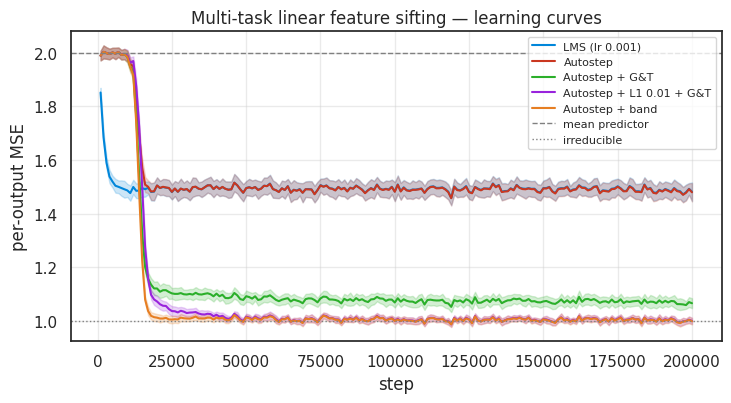

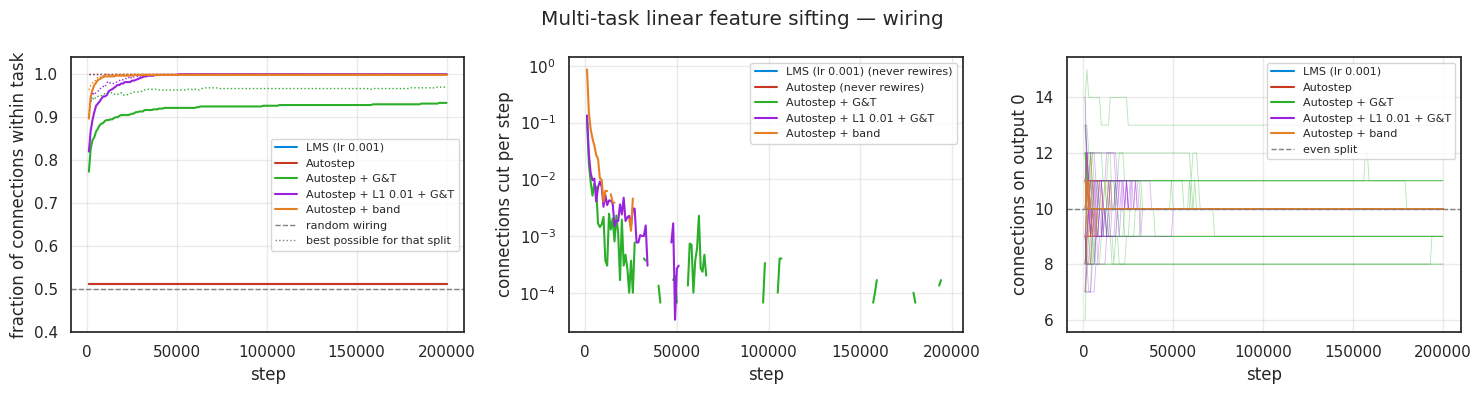

In [10]:
def plot_curves(runs):
    """Per-output MSE per method, mean +- 2 standard errors over seeds."""
    plt.figure(figsize=(7.5, 4.2))
    for (label, res), color in zip(runs.items(), get_color_palette(n=len(runs))):
        mean = res['mse'].mean(0)
        sem = res['mse'].std(0) / np.sqrt(N_SEEDS)
        plt.plot(res['steps'], mean, color=color, label=label)
        plt.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
    plt.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
    plt.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible')
    plt.xlabel('step')
    plt.ylabel('per-output MSE')
    plt.title('Multi-task linear feature sifting — learning curves')
    plt.grid(alpha=0.4)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_wiring(runs):
    """What the rewiring does: how much of it is within-task, how fast it churns, and how the
    connections split between the two outputs (thin lines: individual seeds)."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for (label, res), color in zip(runs.items(), get_color_palette(n=len(runs))):
        axes[0].plot(res['steps'], res['useful'].mean(0), color=color, label=label)
        # An output cannot make more connections within-task than its task has features.
        ceiling = np.minimum(res['per_output'], N_FEATURES_PER_TASK).sum(-1) / N_CONNECTIONS
        axes[0].plot(res['steps'], ceiling.mean(0), color=color, ls=':', lw=1)

        rate = res['cut_rate'].mean(0)
        if np.any(rate > 0):
            axes[1].plot(res['steps'], np.where(rate > 0, rate, np.nan), color=color, label=label)
        else:
            axes[1].plot([], [], color=color, label=f'{label} (never rewires)')

        axes[2].plot(res['steps'], res['per_output'][..., 0].T, color=color, lw=0.6, alpha=0.35)
        axes[2].plot([], [], color=color, label=label)          # legend proxy

    axes[0].axhline(0.5, ls='--', c='gray', lw=1, label='random wiring')
    axes[0].plot([], [], c='gray', ls=':', lw=1, label='best possible for that split')
    axes[0].set_ylabel('fraction of connections within task')
    axes[0].set_ylim(0.4, 1.04)
    axes[1].set_ylabel('connections cut per step')
    axes[1].set_yscale('log')
    axes[2].axhline(N_CONNECTIONS_PER_OUTPUT, ls='--', c='gray', lw=1, label='even split')
    axes[2].set_ylabel('connections on output 0')
    for ax in axes:
        ax.set_xlabel('step')
        ax.grid(alpha=0.4)
        ax.legend(fontsize=8)
    fig.suptitle('Multi-task linear feature sifting — wiring')
    fig.tight_layout()
    plt.show()


plot_curves(runs)
plot_wiring(runs)

The problem with just Autostep + G&T is that the small initial step-size means that some distractor weights will just wander for a very long, long time as almost a random walk before being pulled back and across zero. This is because the strength of the pull scales with the weight manitude, but the random walk does not, so the quickly crossing zero weight behavior only happens with larger step-sizes that cause larger weights.